## Churn Data — Variable Analysis

### By:
jdg

### Date:
2026-03-03

### Description:

Loads the cleaned primary Parquet file produced by
`1-data/02_jdg_churn_data_cleaning_20260221.ipynb`.

Goals:
- Compare numeric feature distributions between churners and non-churners
- Quantify pairwise correlations among numeric features
- Measure churn rates across every categorical and boolean level
- Test the hypothesis that short-tenured customers drive most churn
- Rank all 19 features by association strength with `Churn`

Findings will inform feature engineering decisions in Step 4.

## 📚 Import libraries

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
from scipy.stats import chi2_contingency, pointbiserialr

In [2]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

## 💾 Load data

In [3]:
PRIMARY_PATH = Path("../../data/03_primary/Churn/churn_primary.parquet")

df = pd.read_parquet(PRIMARY_PATH, dtype_backend="numpy_nullable")

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Loaded: 7,194 rows x 20 columns


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,False,True,False,1,False,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,True,Electronic check,29.85,29.85,False
1,Male,False,False,False,34,True,No,DSL,Yes,No,Yes,No,No,No,One year,False,Mailed check,56.95,1889.5,False
2,Male,False,False,False,2,True,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,True,Mailed check,53.85,108.15,True
3,Male,False,False,False,45,False,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,False,Bank transfer (automatic),42.3,1840.75,False
4,Female,False,False,False,2,True,No,Fiber optic,No,No,No,No,No,No,Month-to-month,True,Electronic check,70.7,151.65,True


In [4]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
bool_cols = df.select_dtypes(include="boolean").columns.drop("Churn").tolist()
cat_cols = df.select_dtypes(include="category").columns.tolist()

churn_int = df["Churn"].astype("Int8")

print(f"Numeric  ({len(numeric_cols)}): {numeric_cols}")
print(f"Boolean  ({len(bool_cols)}): {bool_cols}")
print(f"Category ({len(cat_cols)}): {cat_cols}")

Numeric  (3): ['tenure', 'MonthlyCharges', 'TotalCharges']
Boolean  (5): ['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Category (11): ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


## 👷 Variable analysis

### 1. How do numeric features differ between churners and non-churners?

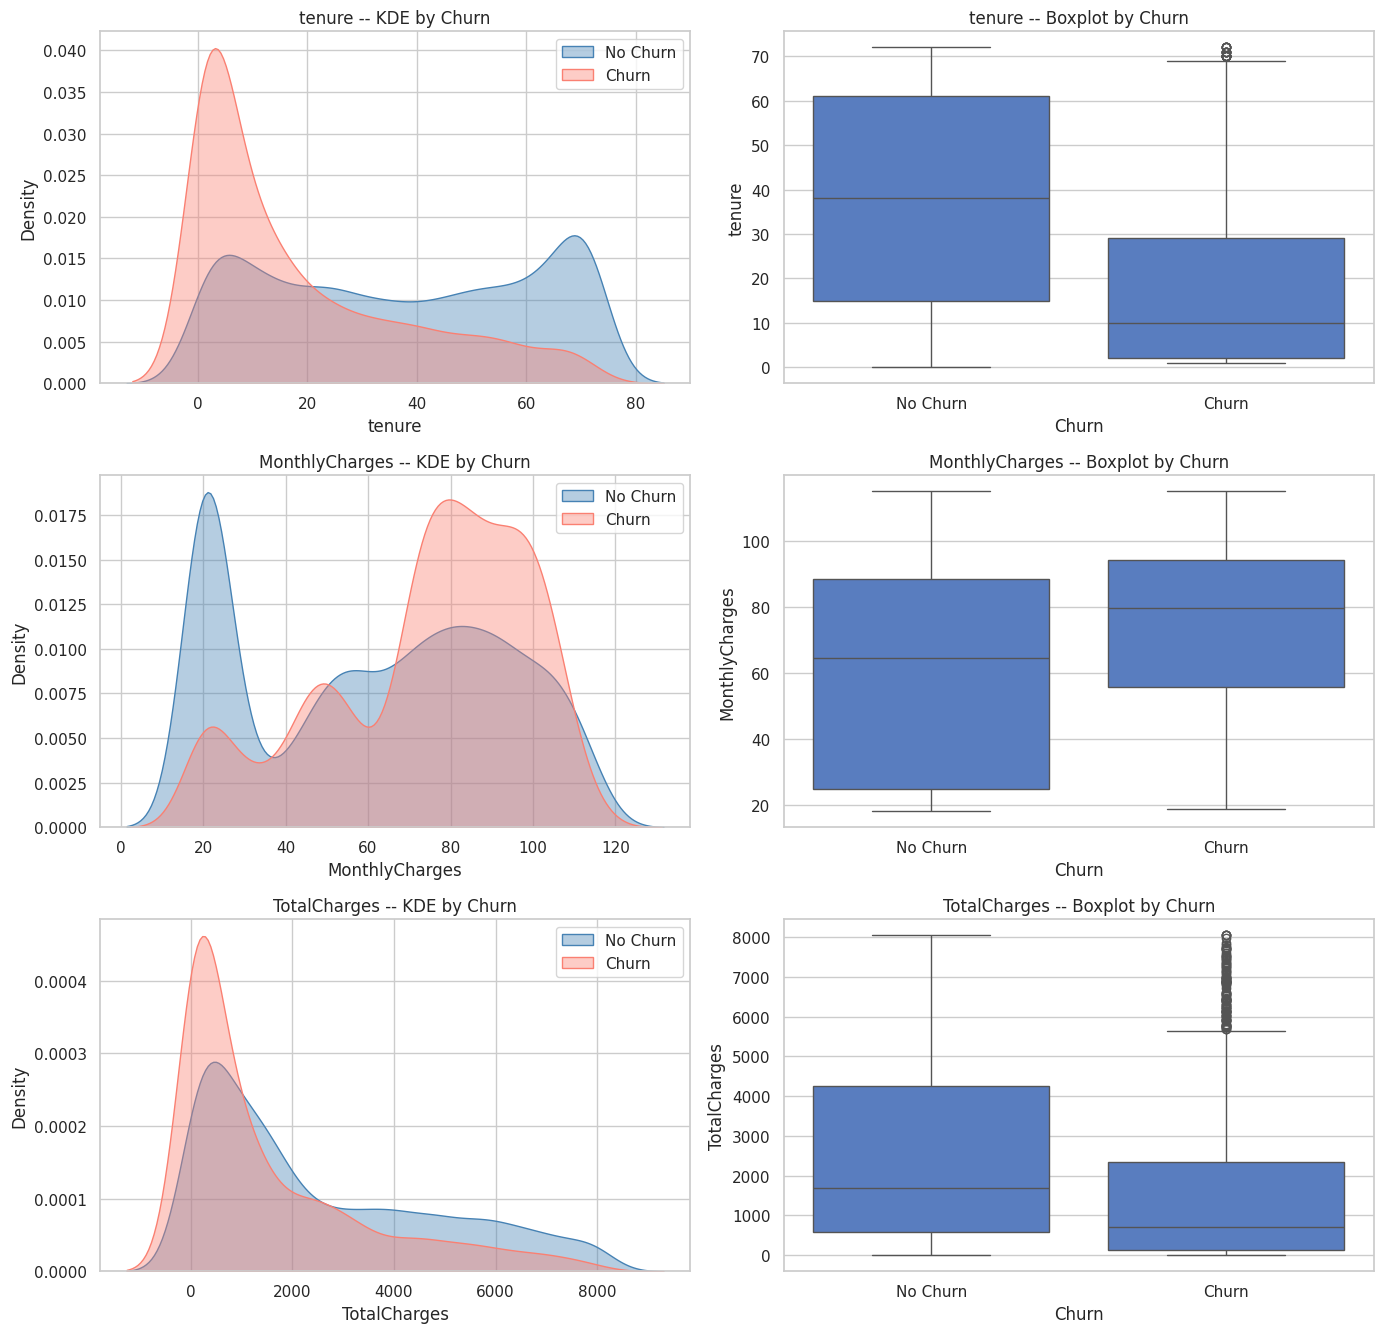

In [5]:
churn_label = df["Churn"].map({True: "Churn", False: "No Churn"})

fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, 4.5 * len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    subset = df[[col]].assign(Churn=churn_label).dropna(subset=[col])

    # KDE plot
    for label, color in zip(["No Churn", "Churn"], ["steelblue", "salmon"], strict=True):
        sns.kdeplot(
            subset.loc[subset["Churn"] == label, col],
            fill=True,
            alpha=0.4,
            label=label,
            color=color,
            ax=axes[i, 0],
        )
    axes[i, 0].set_title(f"{col} -- KDE by Churn")
    axes[i, 0].legend()

    # Boxplot
    sns.boxplot(data=subset, x="Churn", y=col, order=["No Churn", "Churn"], ax=axes[i, 1])
    axes[i, 1].set_title(f"{col} -- Boxplot by Churn")

plt.tight_layout()
plt.show()

### 2. How are the numeric features correlated with each other?

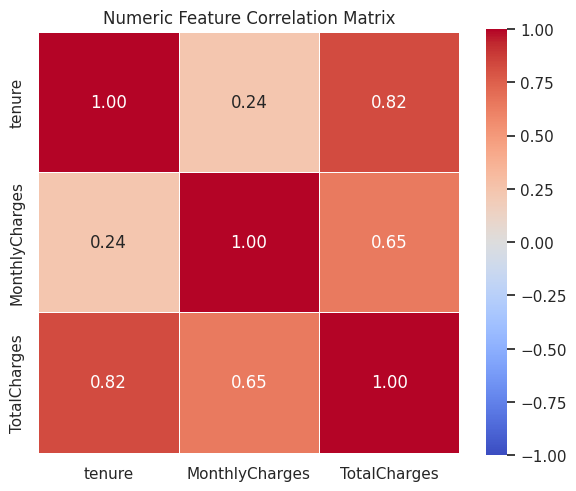

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.240646,0.822713
MonthlyCharges,0.240646,1.000000,0.646116
TotalCharges,0.822713,0.646116,1.000000


In [6]:
corr_df = df[numeric_cols].dropna()
# Convert nullable dtypes to standard float for corr()
corr_matrix = corr_df.astype("float64").corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Numeric Feature Correlation Matrix")
plt.tight_layout()
plt.show()

corr_matrix

### 3. What is the churn rate for each categorical feature level?

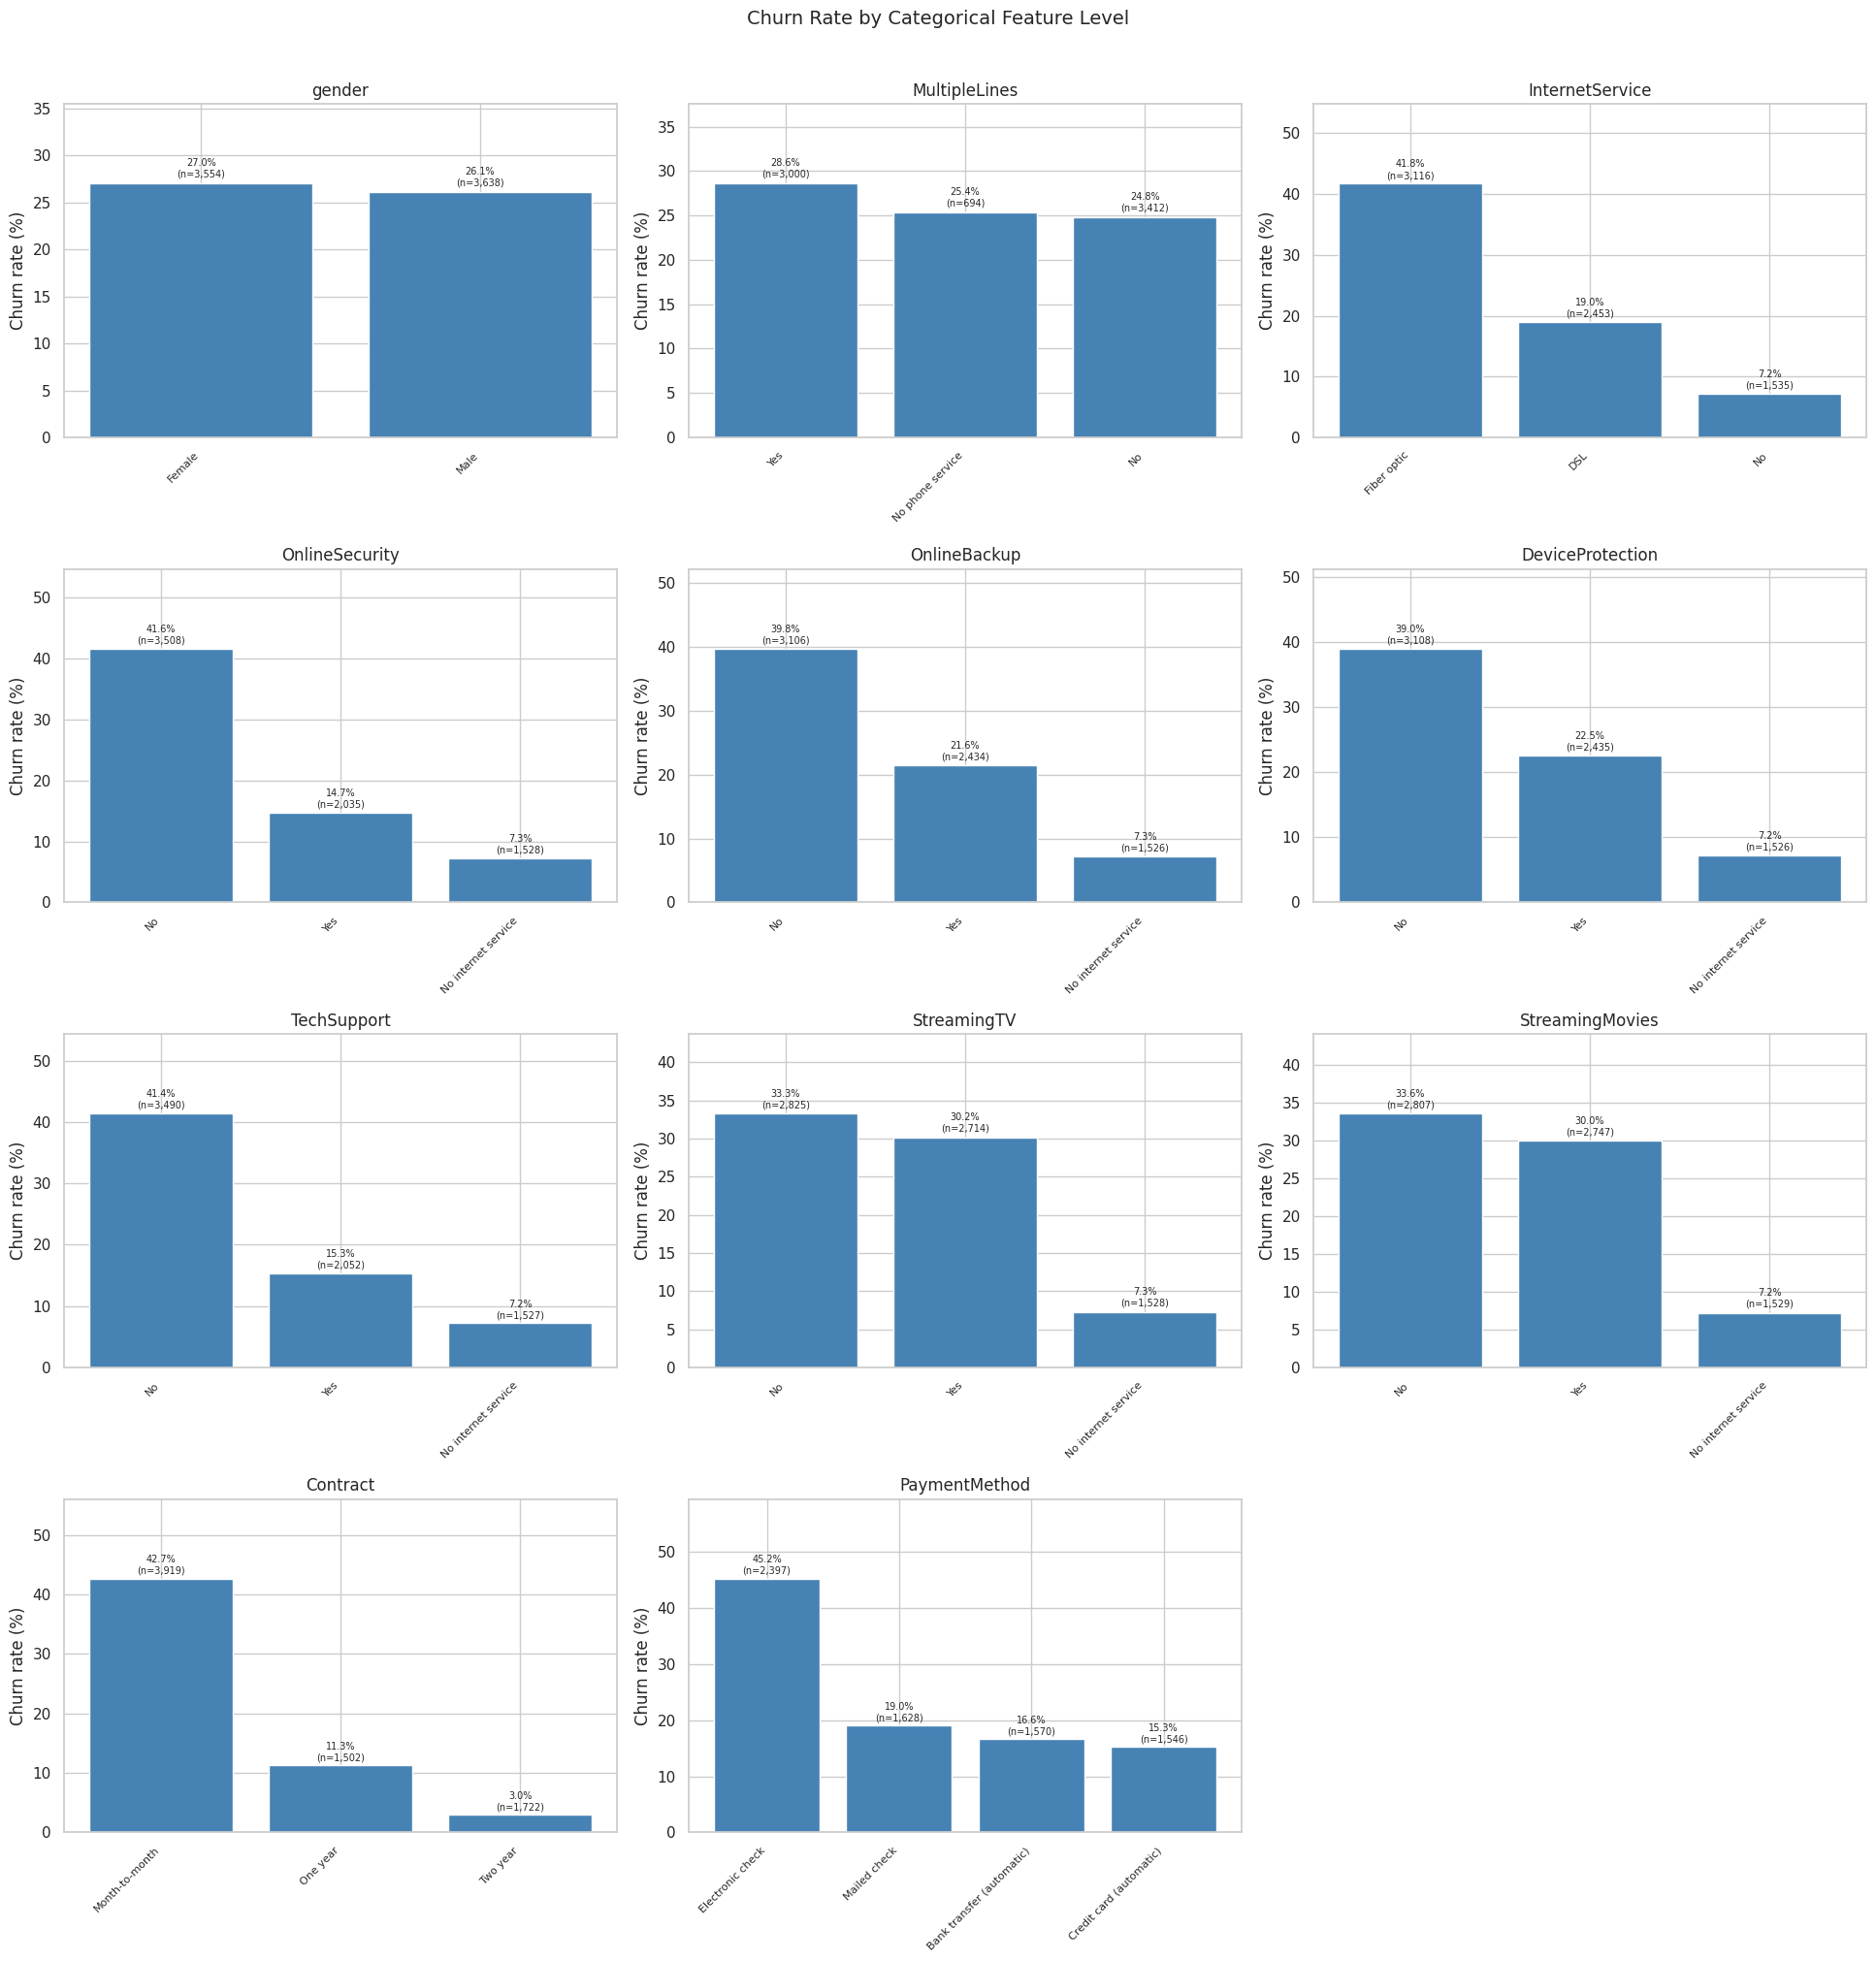

In [7]:
n_plots = len(cat_cols)
n_grid_cols = 3
n_grid_rows = -(-n_plots // n_grid_cols)

fig, axes = plt.subplots(n_grid_rows, n_grid_cols, figsize=(6.5 * n_grid_cols, 5 * n_grid_rows))
axes_flat = axes.flatten()

for i, col in enumerate(cat_cols):
    subset = df[[col, "Churn"]].dropna()
    rates = subset.groupby(col, observed=True)["Churn"].mean().sort_values(ascending=False)
    counts = subset.groupby(col, observed=True)["Churn"].count()

    ax = axes_flat[i]
    bars = ax.bar(range(len(rates)), rates.values * 100, color="steelblue")
    ax.set_xticks(range(len(rates)))
    ax.set_xticklabels(rates.index, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Churn rate (%)")
    ax.set_title(col)

    for bar, rate, level in zip(bars, rates.values, rates.index, strict=True):
        n = counts[level]
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{rate * 100:.1f}%\n(n={n:,})",
            ha="center",
            va="bottom",
            fontsize=7,
        )

    ax.set_ylim(0, ax.get_ylim()[1] * 1.25)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle("Churn Rate by Categorical Feature Level", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 4. How does churn vary across boolean features?

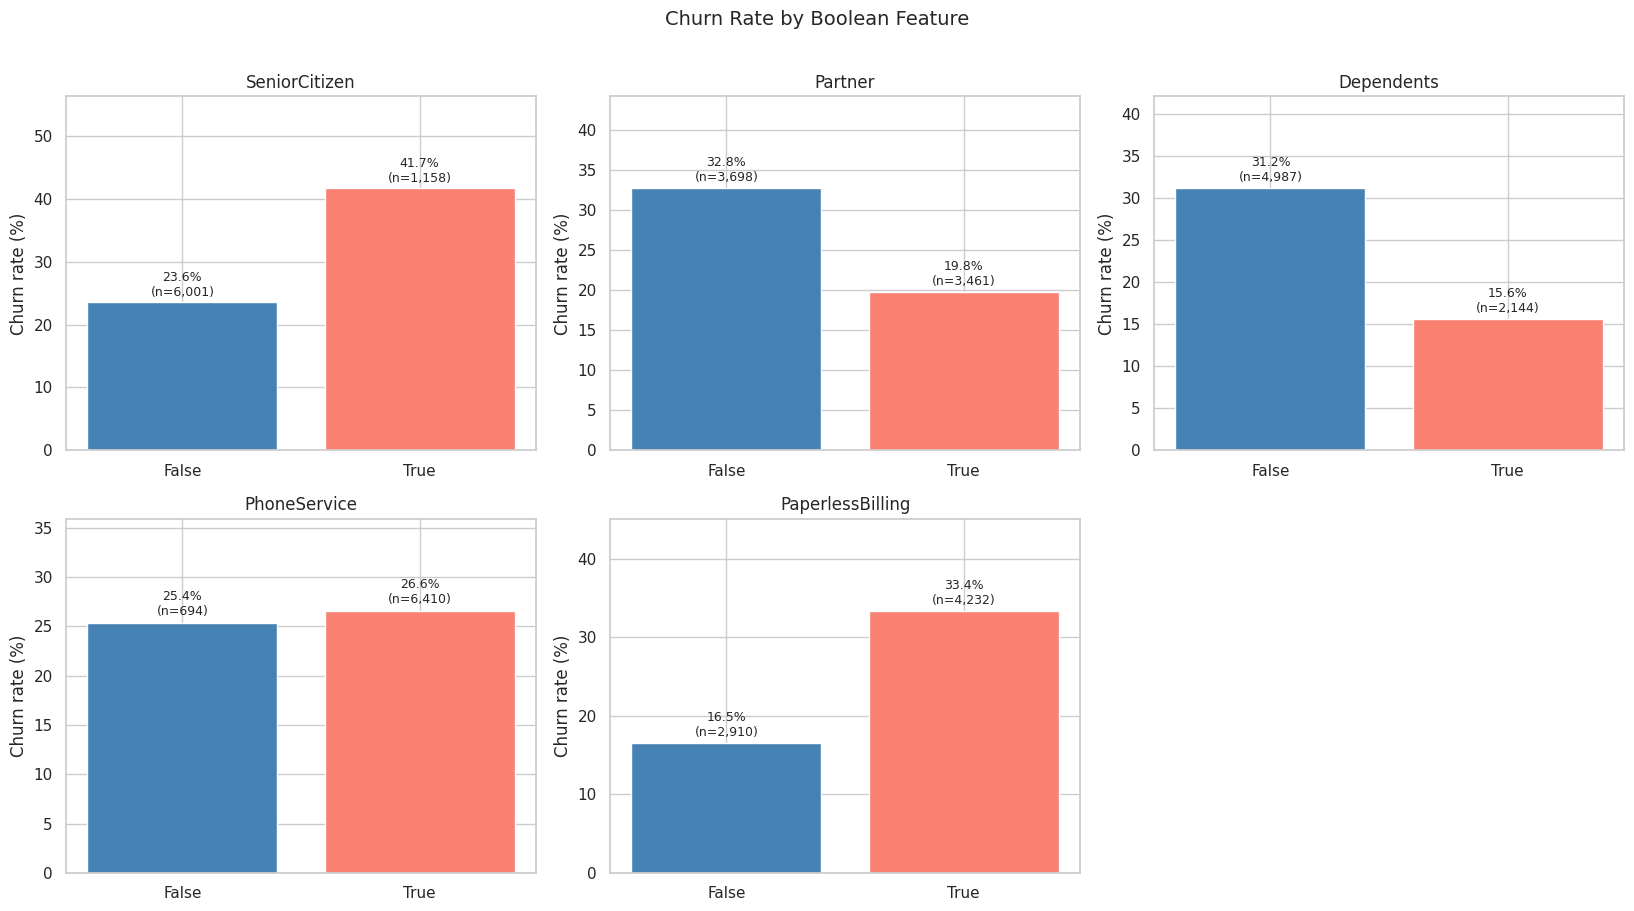

In [8]:
n_plots = len(bool_cols)
n_grid_cols = 3
n_grid_rows = -(-n_plots // n_grid_cols)

fig, axes = plt.subplots(n_grid_rows, n_grid_cols, figsize=(5.5 * n_grid_cols, 4.5 * n_grid_rows))
axes_flat = axes.flatten()

for i, col in enumerate(bool_cols):
    subset = df[[col, "Churn"]].dropna()
    rates = subset.groupby(col, observed=True)["Churn"].mean()
    counts = subset.groupby(col, observed=True)["Churn"].count()

    ax = axes_flat[i]
    labels = ["False", "True"]
    vals = [rates.get(False, 0) * 100, rates.get(True, 0) * 100]
    ns = [counts.get(False, 0), counts.get(True, 0)]
    bars = ax.bar(labels, vals, color=["steelblue", "salmon"])
    ax.set_ylabel("Churn rate (%)")
    ax.set_title(col)

    for bar, rate, n in zip(bars, vals, ns, strict=True):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{rate:.1f}%\n(n={n:,})",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax.set_ylim(0, max(vals) * 1.35)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle("Churn Rate by Boolean Feature", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 5. Do short-tenured customers drive most churn?

                total  churned  churn_rate_pct
tenure_segment                                
0-6              1482      783            52.8
7-12              714      256            35.9
13-24            1041      300            28.8
25-48            1614      330            20.4
49-72            2268      219             9.7


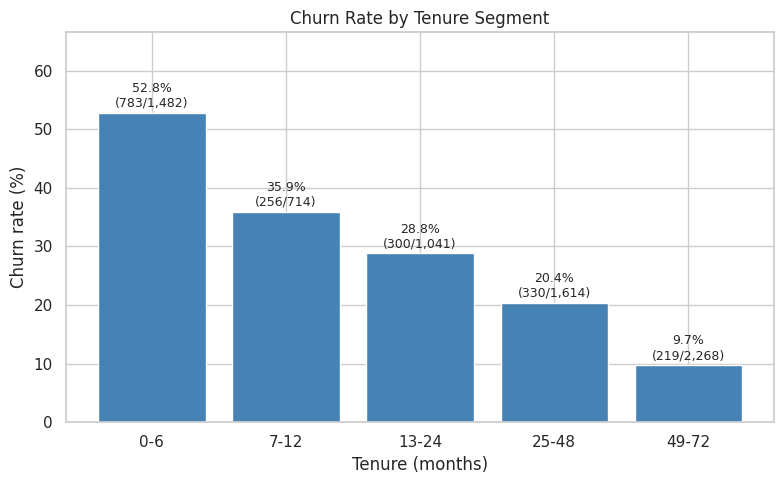

In [9]:
bins = [0, 6, 12, 24, 48, 72]
segment_labels = ["0-6", "7-12", "13-24", "25-48", "49-72"]

tenure_df = df[["tenure", "Churn"]].dropna().copy()
tenure_df["tenure_segment"] = pd.cut(
    tenure_df["tenure"].astype("float64"),
    bins=bins,
    labels=segment_labels,
    include_lowest=True,
)

seg_stats = tenure_df.groupby("tenure_segment", observed=True).agg(
    total=("Churn", "count"),
    churned=("Churn", "sum"),
    churn_rate=("Churn", "mean"),
)
seg_stats["churned"] = seg_stats["churned"].astype(int)
seg_stats["churn_rate_pct"] = (seg_stats["churn_rate"] * 100).round(1)

print(seg_stats[["total", "churned", "churn_rate_pct"]])

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(seg_stats.index.astype(str), seg_stats["churn_rate_pct"], color="steelblue")

for bar, rate, total, churned in zip(
    bars, seg_stats["churn_rate_pct"], seg_stats["total"], seg_stats["churned"], strict=True
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{rate:.1f}%\n({churned:,}/{total:,})",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Churn rate (%)")
ax.set_title("Churn Rate by Tenure Segment")
ax.set_ylim(0, ax.get_ylim()[1] * 1.2)
plt.tight_layout()
plt.show()

### 6. Which features are most strongly associated with churn?

In [10]:
MIN_SAMPLES = 3


def cramers_v(series: pd.Series, target: pd.Series) -> float:
    """Compute Cramer's V between a categorical series and a binary target."""
    ct = pd.crosstab(series, target)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    if k == 0 or n == 0:
        return 0.0
    return float(np.sqrt(chi2 / (n * k)))


def point_biserial(series: pd.Series, target: pd.Series) -> float:
    """Compute point-biserial correlation between a numeric/boolean series and binary target."""
    mask = series.notna() & target.notna()
    x = series[mask].astype("float64")
    y = target[mask].astype("float64")
    if len(x) < MIN_SAMPLES:
        return 0.0
    corr, _ = pointbiserialr(y, x)
    return float(corr)

In [11]:
records = []

for col in numeric_cols:
    r = point_biserial(df[col], df["Churn"])
    records.append({"feature": col, "method": "point-biserial r", "association": abs(r)})

for col in bool_cols:
    r = point_biserial(df[col].astype("Int8"), df["Churn"])
    records.append({"feature": col, "method": "point-biserial r", "association": abs(r)})

for col in cat_cols:
    v = cramers_v(df[col].dropna(), df["Churn"].loc[df[col].notna()])
    records.append({"feature": col, "method": "Cram\u00e9r's V", "association": abs(v)})

assoc_df = pd.DataFrame(records).sort_values("association", ascending=True).reset_index(drop=True)

print(f"Features ranked: {len(assoc_df)}")
assoc_df.sort_values("association", ascending=False)

Features ranked: 19


,feature,method,association
18,Contract,Cramér's V,0.409053
17,tenure,point-biserial r,0.349758
16,OnlineSecurity,Cramér's V,0.346145
15,TechSupport,Cramér's V,0.340995
14,InternetService,Cramér's V,0.322048
13,PaymentMethod,Cramér's V,0.303324
12,OnlineBackup,Cramér's V,0.291862
11,DeviceProtection,Cramér's V,0.281642
10,StreamingMovies,Cramér's V,0.232091
9,StreamingTV,Cramér's V,0.230667


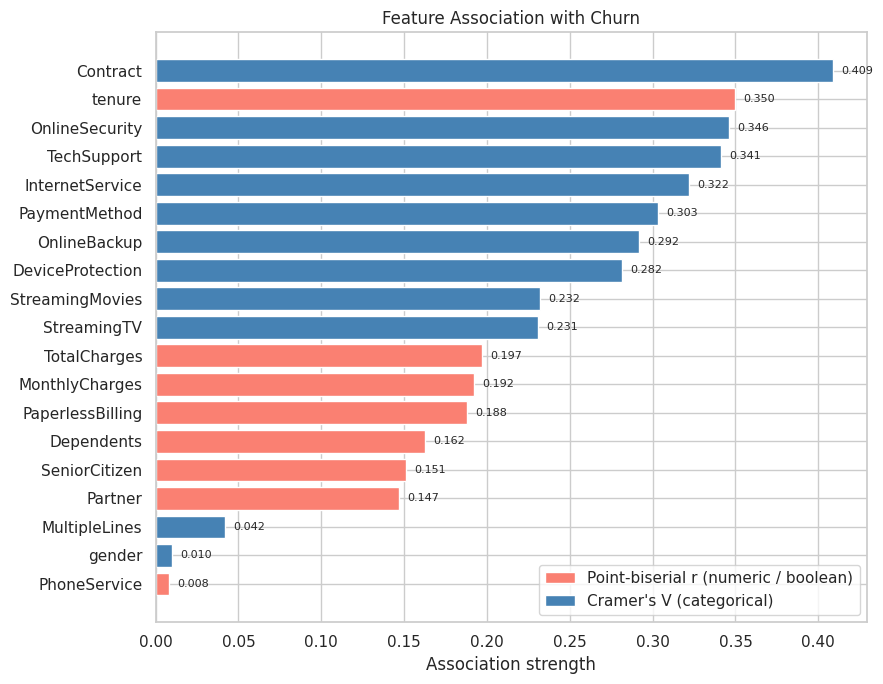

In [12]:
fig, ax = plt.subplots(figsize=(9, 7))

colors = ["salmon" if m == "point-biserial r" else "steelblue" for m in assoc_df["method"]]

ax.barh(assoc_df["feature"], assoc_df["association"], color=colors)
ax.set_xlabel("Association strength")
ax.set_title("Feature Association with Churn")

legend_elements = [
    Patch(facecolor="salmon", label="Point-biserial r (numeric / boolean)"),
    Patch(facecolor="steelblue", label="Cramer's V (categorical)"),
]
ax.legend(handles=legend_elements, loc="lower right")

for j, val in enumerate(assoc_df["association"]):
    ax.text(val + 0.005, j, f"{val:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## 📊 Analysis of Results and Conclusions

- **Contract type is the strongest predictor**: month-to-month customers churn at
  dramatically higher rates than those on one- or two-year contracts. Cramer's V
  confirms this is the categorical feature most associated with churn.
- **Tenure is a key numeric discriminator**: churners concentrate in the first
  0-6 months (highest churn rate by segment), confirming the short-tenure hypothesis.
  Churn rate decreases monotonically with longer tenure.
- **Internet service matters**: fiber optic customers churn more than DSL and
  no-internet customers. Add-on services (OnlineSecurity, TechSupport,
  DeviceProtection) show lower churn when subscribed -- they act as retention
  anchors.
- **MonthlyCharges higher for churners**: the KDE and boxplots show churners pay
  more per month on average. TotalCharges is lower for churners because they
  leave early (short tenure).
- **tenure-TotalCharges correlation is strong** (~0.83), as expected. MonthlyCharges
  has moderate correlation with TotalCharges but low with tenure.
- **Boolean features**: PaperlessBilling and SeniorCitizen show meaningful
  differences in churn rate (paperless billing and seniors churn more). Partner
  and Dependents show moderate effects. PhoneService shows minimal difference.
- **Electronic check payment** has the highest churn rate among payment methods,
  consistent with the hypothesis that automatic payments correlate with retention.
- **`gender` and `PhoneService` show no association** with churn -- both have
  near-zero association scores (0.010 and 0.008 respectively). Neither
  discriminates between churners and non-churners.

## 💡 Proposals and Ideas

- **Drop `gender` and `PhoneService`** -- near-zero association with churn
  (0.010 and 0.008); they add noise without predictive value
- **Drop `TotalCharges`** -- highly correlated with `tenure` (r=0.82) and
  `MonthlyCharges` (r=0.65); it is a derived product of both and carries
  no independent information. Removing it reduces multicollinearity
- **Prioritize high-association features** in feature engineering: `Contract`,
  `InternetService`, `OnlineSecurity`, `TechSupport`, `tenure`,
  `MonthlyCharges`, `PaymentMethod`, `PaperlessBilling`
- **Tenure segmentation feature**: the 0-6 month bucket is a strong signal;
  consider adding a binary `is_new_customer` flag or ordinal tenure buckets
- **Consolidate "No internet/phone service"** levels during encoding: they
  represent service absence and can be merged with "No" for simplicity
- **Encoding strategy**: ordinal encoding for `Contract` (already ordered),
  binary encoding for booleans (already binary), one-hot or target encoding
  for multi-level categoricals
- **Preserve class imbalance** (~26% churn): the imbalanced distribution
  reflects real-world prevalence and is the truth we want models to learn;
  do not apply SMOTE or resampling. Use stratified splits to maintain
  the ratio across train/test sets
- Proceed to `4-feat_eng/` for imputation, encoding, and feature creation

## 📖 References